In [65]:
import warnings
warnings.simplefilter(action='ignore')

In [67]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import sklearn.preprocessing as preprocessing
from sklearn.cluster import KMeans

In [69]:
data = pd.read_csv('dataset/iris_w_header.csv')
print(data)

     sepal_length  sepal_width  petal_length  petal_width           class
0             5.1          3.5           1.4          0.2     Iris-setosa
1             4.9          3.0           1.4          0.2     Iris-setosa
2             4.7          3.2           1.3          0.2     Iris-setosa
3             4.6          3.1           1.5          0.2     Iris-setosa
4             5.0          3.6           1.4          0.2     Iris-setosa
..            ...          ...           ...          ...             ...
145           6.7          3.0           5.2          2.3  Iris-virginica
146           6.3          2.5           5.0          1.9  Iris-virginica
147           6.5          3.0           5.2          2.0  Iris-virginica
148           6.2          3.4           5.4          2.3  Iris-virginica
149           5.9          3.0           5.1          1.8  Iris-virginica

[150 rows x 5 columns]


In [71]:
data = data[['sepal_length', 'petal_length']]
print(data.head())

   sepal_length  petal_length
0           5.1           1.4
1           4.9           1.4
2           4.7           1.3
3           4.6           1.5
4           5.0           1.4


In [73]:
sc = preprocessing.MinMaxScaler()
sc.fit(data)

df_scaled = sc.fit_transform(data)

df_scaled = pd.DataFrame(df_scaled, columns=data.columns)


print(df_scaled.head())

   sepal_length  petal_length
0      0.222222      0.067797
1      0.166667      0.067797
2      0.111111      0.050847
3      0.083333      0.084746
4      0.194444      0.067797


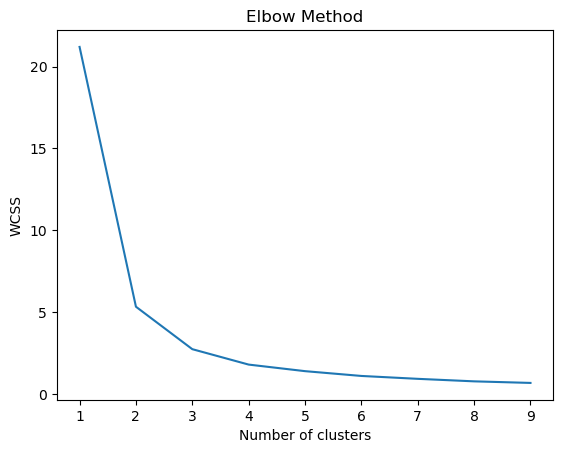

In [75]:
k_values = range(1,10)
wcss = []

for i in k_values:
    ekmeans = KMeans(n_clusters=i, init='k-means++', max_iter=100, n_init=10, random_state=0)
    
    ekmeans.fit(df_scaled)
    
    wcss.append(ekmeans.inertia_)

plt.plot(k_values, wcss)

plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [77]:
ekmeans1 = KMeans(n_clusters=3, init='k-means++', max_iter=100, n_init=10, random_state=0)
pred_y = ekmeans1.fit_predict(df_scaled)

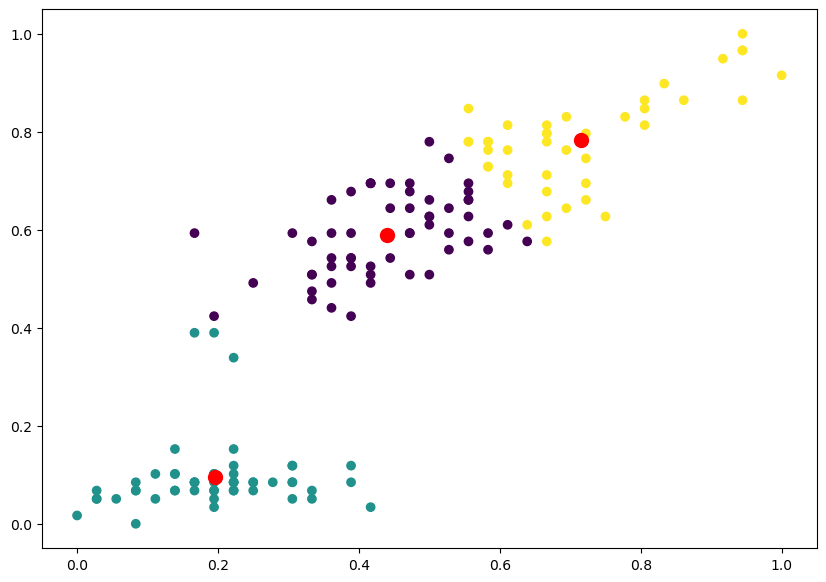

In [79]:
plt.figure(figsize=(10, 7))
plt.scatter(df_scaled['sepal_length'], df_scaled['petal_length'], c=ekmeans1.labels_)
plt.scatter(ekmeans1.cluster_centers_[:, 0], ekmeans1.cluster_centers_[:, 1], s=100, c='red')
plt.show()